In [1]:
import os 
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import sqlalchemy
import psycopg2
import pandas as pd

load_dotenv()

HOST = os.getenv("POSTGIS_HOST")
PORT = int(os.getenv("POSTGIS_PORT"))
USER = os.getenv("POSTGIS_USER")
PASSWORD = os.getenv("POSTGIS_PASSWORD")

engine = create_engine(
    f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/incendies",
    connect_args={"options": "-csearch_path=incendies_schema,public"}
)

# Test de connexion
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version()"))
        print("Connexion réussie !")
        print("Version PostgreSQL :", result.scalar())

        dbs = conn.execute(
            text("SELECT datname FROM pg_database WHERE datistemplate = false ORDER BY datname")
        ).fetchall()
        print("Bases de données :", [db[0] for db in dbs])
except Exception as e:
    print("Erreur de connexion :", e)


Connexion réussie !
Version PostgreSQL : PostgreSQL 17.5 (Debian 17.5-1.pgdg110+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 10.2.1-6) 10.2.1 20210110, 64-bit
Bases de données : ['incendies', 'postgres']


In [2]:
DATABASE_NAME="incendies"

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE_NAME}",
        connect_args={"options": "-csearch_path=incendies,public"},
    )

engine = get_engine()

# Training

## Base DataFrame

### Feature engineering produced a table (related to the other tables, v_commune_paca and incendie) with the following fields:

- id_commune
- date_jour
- has_fire
- nb_incendies_30j
- nb_incendies_90j
- nb_incendies_365j
- surface_totale_5a
- buffer_10km
- buffer_20km
- buffer_50km

In [16]:
import pandas as pd
import numpy as np

# First estimated time : 1mn26s
df = pd.read_sql("""
    SELECT
        cj.id_commune,
        cj.date_jour,
        cj.has_fire,
        cj.nb_incendies_30j,
        cj.nb_incendies_90j,
        cj.nb_incendies_365j,
        cj.surface_totale_5a,
        cj.buffer_10km,
        cj.buffer_20km,
        cj.buffer_50km,
        v.departement,
        v.densite,
        v.superficie_hectare,
        v.altitude_moyenne,
        (v.altitude_maximale - v.altitude_minimale) AS amplitude_altitude
    FROM commune_jour cj
    JOIN v_commune_paca v ON v.id_commune = cj.id_commune
    ORDER BY cj.date_jour, cj.id_commune
    """,
    engine
)
df = df.sort_values(by='date_jour').reset_index(drop=True)

In [17]:
# Make sure we can see all of the columns
pd.set_option('display.max_columns', 500) 
# Keep the output on one page
pd.set_option('display.max_rows', 20)     

df.head(5)

,id_commune,date_jour,has_fire,nb_incendies_30j,nb_incendies_90j,nb_incendies_365j,surface_totale_5a,buffer_10km,buffer_20km,buffer_50km,departement,densite,superficie_hectare,altitude_moyenne,amplitude_altitude
0,1508,2016-01-01,0,0,0,0,0,0,0,1,04,97.0,1463,631,393
1,4390,2016-01-01,0,0,0,1,300,0,0,0,13,1417.0,469,49,105
2,4391,2016-01-01,0,0,0,0,26800,0,0,0,13,634.0,7057,98,272
3,4392,2016-01-01,0,0,0,0,1300,0,0,0,13,615.0,1229,70,176
4,4393,2016-01-01,0,0,1,1,300,0,0,0,13,223.0,3067,106,188


### Features temporelles

In [18]:
# Conversion de la date
df['date_jour'] = pd.to_datetime(df['date_jour'])

# Features Temporelles / Saisonnalité ---
# Jour de la semaine (0 = Lundi, 6 = Dimanche)
df['jour_semaine'] = df['date_jour'].dt.dayofweek

# Encodage cyclique (Jour de l'année)
jour_annee = df['date_jour'].dt.dayofyear
df['sin_jour_annee'] = np.sin(2 * np.pi * jour_annee / 365.25)
df['cos_jour_annee'] = np.cos(2 * np.pi * jour_annee / 365.25)

# Extraction du mois pour le découpage saisonnier
mois = df['date_jour'].dt.month

conditions = [
    mois.isin([12, 1, 2]),
    mois.isin([3, 4, 5]),
    mois.isin([6, 7, 8]),
    mois.isin([9, 10, 11])
]
saisons = ['hiver', 'printemps', 'ete', 'automne']
df['saison'] = np.select(conditions, saisons, default='inconnu')

# One-Hot Encoding des saisons (0 ou 1)
df = pd.get_dummies(df, columns=['saison'], prefix='saison', dtype=int)

In [72]:
df.head(5)

,id_commune,date_jour,has_fire,nb_incendies_30j,nb_incendies_90j,nb_incendies_365j,surface_totale_5a,buffer_10km,buffer_20km,buffer_50km,departement,densite,superficie_hectare,altitude_moyenne,amplitude_altitude,jour_semaine,sin_jour_annee,cos_jour_annee,saison_automne,saison_ete,saison_hiver,saison_printemps,score_histo,score_topo
0,1508,2016-01-01,0,0,0,0,0,0,0,1,04,97.0,1463,631,393,4,0.017202,0.999852,0,0,1,0,0.000000,0.173288
1,4390,2016-01-01,0,0,0,1,300,0,0,0,13,1417.0,469,49,105,4,0.017202,0.999852,0,0,1,0,1.530750,0.000001
2,4391,2016-01-01,0,0,0,0,26800,0,0,0,13,634.0,7057,98,272,4,0.017202,0.999852,0,0,1,0,2.549049,0.000001
3,4392,2016-01-01,0,0,0,0,1300,0,0,0,13,615.0,1229,70,176,4,0.017202,0.999852,0,0,1,0,1.792722,0.000001
4,4393,2016-01-01,0,0,1,1,300,0,0,0,13,223.0,3067,106,188,4,0.017202,0.999852,0,0,1,0,1.669379,0.000001


Remarque : Il serait intéressant de produire une valeur ratio_occupation_sensible, mais elle n'est pas accessible dans cette version : à produire dans une version ultieure (CORINE Land Cover)

### Fonctions de Score (Histo + Topo)

In [ ]:
import numpy as np
import pandas as pd

def calculer_score_histo(
    df: pd.DataFrame,
    w1: float = 0.25,
    w2: float = 0.20,
    w3: float = 0.15,
    w4: float = 0.25,
    w5: float = 0.15,
) -> pd.Series:
  """Calcule le score historique Shisto(c,t) pour chaque ligne du DataFrame.

  Shisto = w1 * ln(1 + nb_incendies_30j)
         + w2 * ln(1 + nb_incendies_90j)
         + w3 * ln(1 + nb_incendies_365j)
         + w4 * ln(1 + surface_totale_5a)
         + w5 * y_t_365
  """
  # Application de la transformation log(1 + x) sur les variables de comptage
  term_30j = np.log1p(df["nb_incendies_30j"])
  term_90j = np.log1p(df["nb_incendies_90j"])
  term_365j = np.log1p(df["nb_incendies_365j"])
  term_surf_5a = np.log1p(df["surface_totale_5a"])

  # Récupération de l'indicateur binaire à t-365j
  y_t_365 = df["y_t_365"] if "y_t_365" in df.columns else 0

  # Combinaison linéaire pondérée
  shisto = (
      w1 * term_30j
      + w2 * term_90j
      + w3 * term_365j
      + w4 * term_surf_5a
      + w5 * y_t_365
  )

  return shisto


def calculer_score_topo(
    df: pd.DataFrame,
    w1: float = 0.25,
    w2: float = 0.25,
    w3: float = 0.25,
    w4: float = 0.25,
    epsilon: float = 1e-6,
) -> pd.Series:
  """Calcule le score topologique Stopo(c,t) pour chaque ligne du DataFrame.

  Stopo = w1 * ln(1 + buffer_10km)
        + w2 * ln(1 + buffer_20km)
        + w3 * ln(1 + buffer_50km)
        + w4 * terme_gravitaire
  """
  # 1. Encodage logarithmique des buffers
  term_10k = np.log1p(df["buffer_10km"])
  term_20k = np.log1p(df["buffer_20km"])
  term_50k = np.log1p(df["buffer_50km"])

  # Terme gravitaire sum(surf_j / d_cj^2)
  # Si la colonne précalculée existe dans le DataFrame, sinon 0
  terme_gravitaire = (
      df["terme_gravitaire_50km"] if "terme_gravitaire_50km" in df.columns else 0
  )

  # Combinaison linéaire pondérée avec le terme de lissage epsilon
  stopo = (
      w1 * term_10k
      + w2 * term_20k
      + w3 * term_50k
      + w4 * terme_gravitaire
      + epsilon
  )

  return stopo


# Exemple d'intégration dans le DataFrame
df["score_histo"] = calculer_score_histo(df)

# Exemple d'application dans le DataFrame
df["score_topo"] = calculer_score_topo(df)

## Split

### Définition de X_train, y_train, X_test, y_test

In [74]:
feature_cols = [
    # Spatial / Densité / Relief / Occupation du sol
    'densite',
    'superficie_hectare',
    'altitude_moyenne',
    'amplitude_altitude',
    
    # Saisonnalité & Temporel
    'jour_semaine',
    'sin_jour_annee',
    'cos_jour_annee',
    'saison_automne',
    'saison_ete',
    'saison_hiver',
    'saison_printemps',
    
    # Historique & Buffers
    'nb_incendies_30j',
    'nb_incendies_90j',
    'nb_incendies_365j',
    'surface_totale_5a',
    'buffer_10km',
    'buffer_20km',
    'buffer_50km',

    # Scores
    'score_histo',
    'score_topo'
]


In [84]:
# Gestion du split spatial et temporel
df['date_jour'] = pd.to_datetime(df['date_jour'])
depts_test = ['06']
date_coupure = '2023-01-01'


# Construction des masques de filtrage
mask_train_space = df['departement'].astype(str).str.zfill(2).isin(depts_test)
mask_test_space = df['departement'].astype(str).str.zfill(2).isin(depts_test)

mask_train_time = df['date_jour'] < date_coupure
mask_test_time = df['date_jour'] >= date_coupure

df_train = df[mask_train_space & mask_train_time]
df_test = df[mask_test_space & mask_test_time]

# Définition de X_train, y_train, X_test, y_test
X_train = df_train[feature_cols]
y_train = df_train['has_fire']
X_test = df_test[feature_cols]
y_test = df_test['has_fire']

print(f"Train: {X_train.shape[0]} lignes | Ratio de feux: {y_train.mean():.2%}")
print(f"Test : {X_test.shape[0]} lignes | Ratio de feux: {y_test.mean():.2%}")

Train: 416791 lignes | Ratio de feux: 0.14%
Test : 178648 lignes | Ratio de feux: 0.14%


## Training

In [114]:
%pip install -q xgboost
%pip install -q imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [113]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# For later use
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import matplotlib.pyplot as plt

### Confusion Matrix

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def get_confusion_matrix(model, threshold):

    y_proba = model.predict_proba(X_test)[:, 1]

    y_pred_custom = (y_proba >= threshold).astype(int)

    # 2. Calcul de la matrice de confusion (Format: [[TN, FP], [FN, TP]])
    cm = confusion_matrix(y_test, y_pred_custom)
    tn, fp, fn, tp = cm.ravel()

    # 3. Affichage textuel détaillé dans le terminal
    total_neg = tn + fp
    total_pos = fn + tp
    total_samples = len(y_test)

    print("=" * 50)
    print(f"MATRICE DE CONFUSION (Seuil = {threshold:.4f})")
    print("=" * 50)
    print(f"Vrais Négatifs  (TN) : {tn:>10,d}  ({tn/total_neg:.2%} des journées sans feu)")
    print(f"Faux Positifs   (FP) : {fp:>10,d}  ({fp/total_neg:.2%} des journées sans feu -> Fous de rage / Fausses alertes)")
    print(f"Faux Négatifs   (FN) : {fn:>10,d}  ({fn/total_pos:.2%} des feux réels -> Manqués !)")
    print(f"Vrais Positifs  (TP) : {tp:>10,d}  ({tp/total_pos:.2%} des feux réels -> Détectés !)")
    print("-" * 50)
    print(f"Total Échantillons Test : {total_samples:>10,d}")
    print("=" * 50)

    # 4. Affichage sous forme de Heatmap Seaborn
    plt.figure(figsize=(8, 6))
    cm_df = pd.DataFrame(
        cm, 
        index=['Pas de Feu (Réel)', 'Feu (Réel)'], 
        columns=['Pas de Feu (Prédit)', 'Feu (Prédit)']
    )

    sns.heatmap(cm_df, annot=True, fmt=',d', cmap='Blues', cbar=False, annot_kws={"size": 12})
    plt.title(f'Matrice de Confusion — Seuil Opérationnel : {results['XGBoost']['best_threshold']:.4f}')
    plt.ylabel('Classe Réelle')
    plt.xlabel('Classe Prédite')
    plt.tight_layout()
    plt.show()

### Training v1

In [ ]:
  
# Calcul du ratio de déséquilibre
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
}

model_grids = {
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        # valeurs modérées (3 à 7)
        'max_depth': [3, 5, 7],
        # avoid l'overfitting
        'subsample': [0.8, 1.0] 
    }
}


In [34]:
def evaluate_classifier_with_gridsearch_v1(name, model, grid, X_train, y_train, X_test, y_test):
    # Recherche d'hyperparamètres ou entraînement simple
    if grid:
        # clf = GridSearchCV(model, grid, cv=3, scoring='roc_auc', n_jobs=-1)
        # 3 ou 4 processeurs max au lieu de -1
        clf = GridSearchCV(model, grid, cv=3, scoring='roc_auc', n_jobs=4)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()
    
    # Prédictions des classes et des probabilités
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Test d'un seuil plus bas (ex: 0.15)
    threshold = 0.15
    y_pred_adjusted = (y_proba >= threshold).astype(int)
    
    # Calcul des métriques de classification
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # Vérification du résultat dans le terminal
    print(f"=== {name} ===")
    print(f"ROC AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc,
        'model': best_model,
        'params': best_params
    }



In [ ]:
results = {}
for name, model in models.items():
    results[name] = evaluate_classifier_with_gridsearch_v1(
        name, model, model_grids.get(name, {}), X_train, y_train, X_test, y_test
    )

# ROC AUC: 0.7532 | Accuracy: 0.8503 | F1-Score: 0.0079

### Training v2

In [ ]:
def evaluate_classifier_with_gridsearch_v2(name, model, grid, X_train, y_train, X_test, y_test):
    # Recherche d'hyperparamètres ou entraînement simple
    if grid:              
        clf = GridSearchCV(model, grid, cv=3, scoring='roc_auc', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()
    
    # Prédictions des classes et des probabilités
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Recherche automatique du seuil optimal pour maximiser le F1-Score
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]          
    
    # Prédictions des classes avec le seuil optimal
    y_pred_opt = (y_proba >= best_thresh).astype(int) 
    
    # Calcul des métriques avec le seuil optimal
    acc_opt = accuracy_score(y_test, y_pred_opt)
    prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
    rec_opt = recall_score(y_test, y_pred_opt, zero_division=0)
    f1_opt = f1_scores[best_idx]
    auc = roc_auc_score(y_test, y_proba)
    
    # Vérification du résultat dans le terminal
    print(f"=== {name} ===")
    print(f"ROC AUC: {auc:.4f} | Seuil Optimal: {best_thresh:.4f}")
    print(f"F1-Score: {f1_opt:.4f} | Rappel: {rec_opt:.4f} | Précision: {prec_opt:.4f} | Accuracy: {acc_opt:.4f}\n")
    

    return {
        'best_threshold': best_thresh,
        'f1_score_opt': f1_opt,
        'recall_opt': rec_opt,
        'precision_opt': prec_opt,
        'accuracy_opt': acc_opt,
        'roc_auc': auc,
        'model': best_model,
        'params': best_params
    }

In [36]:
results = {}
for name, model in models.items():
    results[name] = evaluate_classifier_with_gridsearch_v2(
        name, model, model_grids.get(name, {}), X_train, y_train, X_test, y_test
    )

=== XGBoost ===
ROC AUC: 0.7532 | Seuil Optimal: 0.8151
F1-Score: 0.0208 | Rappel: 0.0947 | Précision: 0.0117 | Accuracy: 0.9879



### Traaining v3


In [37]:
# Convertir y_train 
n_pos = int(np.sum(y_train))
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

# Définition du modèle de base
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
}

# Grille d'hyperparamètres
model_grids = {
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

In [38]:
def evaluate_classifier_with_gridsearch_v3(name, model, grid, X_train, y_train, X_test, y_test):
    # Recherche d'hyperparamètres ou entraînement simple
    if grid:              
        clf = GridSearchCV(model, grid, cv=3, scoring='f1', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()
    
    # Prédictions des classes et des probabilités
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Recherche automatique du seuil optimal pour maximiser le F1-Score
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]          
    
    # Prédictions des classes avec le seuil optimal
    y_pred_opt = (y_proba >= best_thresh).astype(int) 
    
    # Calcul des métriques avec le seuil optimal
    acc_opt = accuracy_score(y_test, y_pred_opt)
    prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
    rec_opt = recall_score(y_test, y_pred_opt, zero_division=0)
    f1_opt = f1_scores[best_idx]
    auc = roc_auc_score(y_test, y_proba)
    
    # Vérification du résultat dans le terminal
    print(f"=== {name} ===")
    print(f"ROC AUC: {auc:.4f} | Seuil Optimal: {best_thresh:.4f}")
    print(f"F1-Score: {f1_opt:.4f} | Rappel: {rec_opt:.4f} | Précision: {prec_opt:.4f} | Accuracy: {acc_opt:.4f}\n")

    return {
        'best_threshold': best_thresh,
        'f1_score_opt': f1_opt,
        'recall_opt': rec_opt,
        'precision_opt': prec_opt,
        'accuracy_opt': acc_opt,
        'roc_auc': auc,
        'model': best_model,
        'params': best_params
    }

In [39]:
results = {}
for name, model in models.items():
    results[name] = evaluate_classifier_with_gridsearch_v3(
        name, model, model_grids.get(name, {}), X_train, y_train, X_test, y_test
    )

=== XGBoost ===
ROC AUC: 0.7047 | Seuil Optimal: 0.8170
F1-Score: 0.0239 | Rappel: 0.0329 | Précision: 0.0188 | Accuracy: 0.9963



### Training v4

In [54]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    max_delta_step=1,
    random_state=42,
    n_jobs=4
)


def evaluate_classifier_with_gridsearch_v4(name, model, grid, X_train, y_train, X_test, y_test):
    # Recherche d'hyperparamètres ou entraînement simple
    if grid:              
        clf = GridSearchCV(model, grid, cv=3, scoring='average_precision', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()
    
    # Prédictions des classes et des probabilités
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Recherche automatique du seuil optimal pour maximiser le F1-Score
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Recherche du seuil pour un Rappel cible (ex: 70%)
    target_recall = 0.70
    
    # Sécurité au cas où aucun seuil ne satisfait la condition
    valid_indices = np.where(recalls >= target_recall)[0]
    if len(valid_indices) > 0:
        idx = valid_indices[-1] # Dernier indice correspondant à target_recall
        custom_thresh = thresholds[idx] if idx < len(thresholds) else thresholds[-1]
        custom_prec = precisions[idx]
        custom_rec = recalls[idx]
    else:
        custom_thresh = 0.5
        custom_prec, custom_rec = 0.0, 0.0

    print(f"=== {name} ===")
    print(f"--- Seuil pour Rappel >= {target_recall*100}% ---")
    print(f"Seuil requis : {custom_thresh:.4f}")
    print(f"Rappel       : {custom_rec:.4f}")
    print(f"Précision    : {custom_prec:.4f}")      
    
    # Application du nouveau seuil sur le jeu de test
    y_pred_custom = (y_proba >= custom_thresh).astype(int)
    
    # Métriques globales calculées avec ce seuil métier
    f1_custom = f1_score(y_test, y_pred_custom, zero_division=0)
    acc_custom = accuracy_score(y_test, y_pred_custom)
    auc = roc_auc_score(y_test, y_proba)

    print(f"F1-Score     : {f1_custom:.4f}")
    print(f"ROC AUC      : {auc:.4f}\n")

    return {
        'best_threshold': custom_thresh,
        'f1_score_opt': f1_custom,
        'recall_opt': custom_rec,
        'precision_opt': custom_prec,
        'accuracy_opt': acc_custom,
        'roc_auc': auc,
        'model': best_model,
        'params': best_params
    }

In [92]:
results = {}
for name, model in models.items():
    results[name] = evaluate_classifier_with_gridsearch_v4(
        name, model, model_grids.get(name, {}), X_train, y_train, X_test, y_test
    )

=== XGBoost ===
--- Seuil pour Rappel >= 70.0% ---
Seuil requis : 0.3275
Rappel       : 0.7037
Précision    : 0.0027
F1-Score     : 0.0055
ROC AUC      : 0.7444



MATRICE DE CONFUSION (Seuil = 0.3275)
Vrais Négatifs  (TN) :    116,159  (65.11% des journées sans feu)
Faux Positifs   (FP) :     62,246  (34.89% des journées sans feu -> Fous de rage / Fausses alertes)
Faux Négatifs   (FN) :         72  (29.63% des feux réels -> Manqués !)
Vrais Positifs  (TP) :        171  (70.37% des feux réels -> Détectés !)
--------------------------------------------------
Total Échantillons Test :    178,648


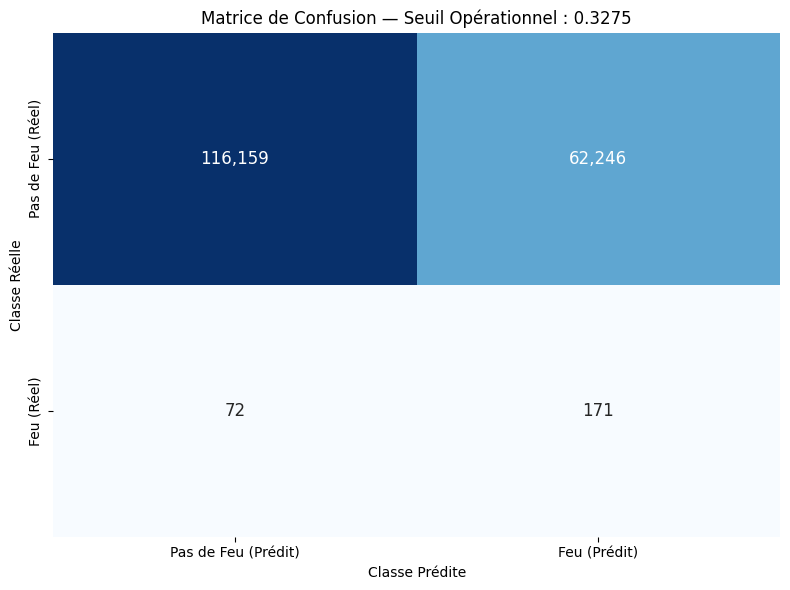

In [112]:
get_confusion_matrix(model = results['XGBoost']['model'], threshold = results['XGBoost']['best_threshold'])

### L'undersampling aléatoire

L’undersampling ciblé (ou sous-échantillonnage intelligent) est une stratégie avancée de gestion du déséquilibre de classes. Contrairement à un sous-échantillonnage aléatoire classique (Random Undersampling), qui supprime aveuglément des exemples de la classe majoritaire au risque de détruire des informations cruciales, l'undersampling ciblé s'appuie sur la topologie de l'espace des descripteurs (l'espace des features) pour éliminer sélectivement les individus majoritaires inutiles ou néfastes.

Dans des problématiques à fort déséquilibre comme la prédiction du risque d'incendie ou la détection de fraude, cette approche est particulièrement puissante.

In [118]:
def undersampling_training(X_train,y_train,X_test,y_test):

    rus = RandomUnderSampler(sampling_strategy=0.05, random_state=42)
    X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

    print(f"Taille X_train initial  : {X_train.shape[0]:,} lignes (dont {y_train.sum():,} feux)")
    print(f"Taille X_train réduit   : {X_train_res.shape[0]:,} lignes (dont {y_train_res.sum():,} feux)\n")

    # On recalcule scale_pos_weight sur les données sous-échantillonnées
    scale_pos_weight_res = (len(y_train_res) - y_train_res.sum()) / y_train_res.sum()

    model_rus = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_res,
        max_delta_step=1, 
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=4
    )

    model_rus.fit(X_train_res, y_train_res)
    params_opt = model_rus.get_params()

    # Recherche du seuil garantissant 70% de Rappel
    y_proba = model_rus.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    target_recall = 0.70

    valid_indices = np.where(recalls >= target_recall)[0]
    idx = valid_indices[-1] if len(valid_indices) > 0 else -1
    custom_thresh = thresholds[idx] if idx < len(thresholds) else 0.5

    # Prédictions ajustées
    y_pred_opt = (y_proba >= custom_thresh).astype(int)

    # Bilan
    prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
    rec_opt = recall_score(y_test, y_pred_opt, zero_division=0)
    acc_opt = accuracy_score(y_test, y_pred_opt)
    f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

    print("=" * 55)
    print("  RÉSULTATS AVEC UNDERSAMPLING (RUS) SUR X_TRAIN")
    print("=" * 55)
    print(f"ROC AUC             : {auc:.4f}")
    print(f"Seuil de décision   : {custom_thresh:.4f}")
    print(f"Rappel (Recall)     : {rec_opt:.2%} (Cible : >= {target_recall*100:.0f}%)")
    print(f"Précision           : {prec_opt:.2%}")
    print(f"F1-Score            : {f1_opt:.4f}")
    print("-" * 55)
    print(f"Vrais Positifs (TP) : {tp:>8,d} feux détectés")
    print(f"Faux Positifs  (FP) : {fp:>8,d} fausses alertes")
    print(f"Faux Négatifs  (FN) : {fn:>8,d} feux manqués")
    print(f"Vrais Négatifs (TN) : {tn:>8,d} journées calmes bien prédites")
    print("=" * 55)

    return {
        'best_threshold': custom_thresh,
        'f1_score_opt': f1_opt,
        'recall_opt': rec_opt,
        'precision_opt': prec_opt,
        'accuracy_opt': acc_opt,
        'roc_auc': auc,
        'model': model_rus,
        'params' : params_opt
    }

In [119]:
results = {}
for name, model in models.items():
    results[name] = undersampling_training(X_train,y_train,X_test,y_test)

Taille X_train initial  : 416,791 lignes (dont 572 feux)
Taille X_train réduit   : 12,012 lignes (dont 572 feux)

  RÉSULTATS AVEC UNDERSAMPLING (RUS) SUR X_TRAIN
ROC AUC             : 0.7581
Seuil de décision   : 0.3875
Rappel (Recall)     : 70.37% (Cible : >= 70%)
Précision           : 0.27%
F1-Score            : 0.0055
-------------------------------------------------------
Vrais Positifs (TP) :      171 feux détectés
Faux Positifs  (FP) :   62,255 fausses alertes
Faux Négatifs  (FN) :       72 feux manqués
Vrais Négatifs (TN) :  116,150 journées calmes bien prédites


Progression du ROC AUC ($0,7581$ vs $0,7432$) : L'ajout explicite des deux scores synthétiques apporte un léger gain de pouvoir séparateur ($+0,015$ point d'AUC).

Hausse du seuil de décision ($0,3875$ vs $0,2971$) : Le modèle est devenu globalement plus confiant dans ses prédictions positives, ce qui permet de remonter le seuil d'alerte tout en maintenant le contrat des $70,37\%$ de Rappel.

Précision stable à $0,27\%$ : Elle reste le reflet mathématique du manque de variables météorologiques en temps réel (vent/humidité/sécheresse).

## Sauvegarde du modèle

In [ ]:
from pathlib import Path
import joblib

ROOT = Path.cwd().parents[1]

models_dir = ROOT / 'app/streamlit/models'
models_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    'model': results['XGBoost']['model'], 
    'threshold': results['XGBoost']['best_threshold']
}

joblib.dump(artifact, models_dir / 'xgb_model.joblib')

['/home/philippe/work-plateforme/incendies/app/streamlit/models/xgb_model.joblib']

On doit faire un build de app : 
- docker compose up -d --build app

#### Update Dockerfile

In [ ]:
# # Dockerfile
# FROM python:3.12-slim

# # XGBoost nécessite OpenMP, absent de l'image slim
# RUN apt-get update \
#     && apt-get install -y --no-install-recommends libgomp1 \
#     && rm -rf /var/lib/apt/lists/*

# WORKDIR /app
# COPY requirements.txt .
# RUN pip install --no-cache-dir -r requirements.txt
# COPY . .

# EXPOSE 8501
# CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=8501"]


In [ ]:
import joblib
import pandas as pd
import numpy as np

# Chargement de l'artefact sauvegardé
ROOT = Path.cwd().parents[1]
models_dir = ROOT / 'app/streamlit/models'

artifact = joblib.load(models_dir / 'xgb_model.joblib')
artifact['features'] = list(model.feature_names_in_)

model = artifact['model']
threshold = artifact['threshold']
feature_names = artifact['features'] 

print(f"Modèle chargé avec succès.")
print(f"Seuil opérationnel retenu : {threshold:.4f}")
print(f"Nombre de variables attendues : {len(feature_names)}")

# Prédiction sur le jeu de test existant (X_test)
# On s'assure d'aligner strictment les colonnes dans l'ordre attendu
X_test_aligned = X_test[feature_names]

# Calcul des probabilités brutes (entre 0 et 1)
y_proba_test = model.predict_proba(X_test_aligned)[:, 1]

# Application du seuil calibré pour obtenir la classe binaire (0 ou 1)
y_pred_test = (y_proba_test >= threshold).astype(int)

# Affichage des 5 premiers résultats
df_results_test = pd.DataFrame({
    'Probabilite': y_proba_test[:5],
    'Prediction_Alerte': y_pred_test[:5],
    'Reel': y_test.iloc[:5].values
})
print("\n--- Exemple de prédictions sur X_test ---")
print(df_results_test)


# Prédiction sur une nouvelle observation unique
# Création d'une ligne d'exemple avec les variables de base
nouvelle_commune = {
    'densite': 250.0,
    'superficie_hectare': 1500.0,
    'altitude_moyenne': 400.0,
    'amplitude_altitude': 300.0,
    'jour_semaine': 2,
    'sin_jour_annee': np.sin(2 * np.pi * 200 / 365), # Mi-juillet
    'cos_jour_annee': np.cos(2 * np.pi * 200 / 365),
    'saison_automne': 0,
    'saison_ete': 1,
    'saison_hiver': 0,
    'saison_printemps': 0,
    'nb_incendies_30j': 2,
    'nb_incendies_90j': 4,
    'nb_incendies_365j': 10,
    'surface_totale_5a': 60.0,
    'buffer_10km': 3,
    'buffer_20km': 8,
    'buffer_50km': 15
}

df_single = pd.DataFrame([nouvelle_commune])

# Calcul dynamique des 2 scores requis
df_single['score_histo'] = calculer_score_histo(df_single)
df_single['score_topo'] = calculer_score_topo(df_single)

# Alignement strict sur les 20 features
X_single = df_single[feature_names]

# Inférence
proba = model.predict_proba(X_single)[:, 1][0]
is_alert = proba >= threshold

print("\n--- Résultat pour la nouvelle observation ---")
print(f"Probabilité de risque calculée : {proba:.2%}")
print(f"Seuil d'alerte                 : {threshold:.2%}")
print(f"Statut d'alerte                : {'🚨 ALERTE RISQUE ÉLEVÉ' if is_alert else '✅ RISQUE FAIBLE/MODÉRÉ'}")

Modèle chargé avec succès.
Seuil opérationnel retenu : 0.3875
Nombre de variables attendues : 20

--- Exemple de prédictions sur X_test ---
   Probabilite  Prediction_Alerte  Reel
0     0.026314                  0     0
1     0.013989                  0     0
2     0.014715                  0     0
3     0.049749                  0     0
4     0.319584                  0     0

--- Résultat pour la nouvelle observation ---
Probabilité de risque calculée : 69.54%
Seuil d'alerte                 : 38.75%
Statut d'alerte                : 🚨 ALERTE RISQUE ÉLEVÉ
